In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")

fold0_1["fold"] = [0 for i in range(len(fold0_1))]
fold0_1["target"] = [1.0 for i in range(len(fold0_1))]

In [3]:
fold1_1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")

fold1_1["fold"] = [1 for i in range(len(fold1_1))]
fold1_1["target"] = [1.0 for i in range(len(fold1_1))]

In [4]:
fold2_1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")

fold2_1["fold"] = [2 for i in range(len(fold2_1))]
fold2_1["target"] = [1.0 for i in range(len(fold2_1))]

In [5]:
df = pd.concat([fold0_1, fold1_1, fold2_1], ignore_index=True)

In [6]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'dot7_result', 'dot7_target', 'dot7_init', 'dot11_result',
       'dot11_target', 'dot11_init', 'dot15_result', 'dot15_target',
       'dot15_init', 'num_edits_slice0', 'num_edits_slice1', 'GC_seq',
       'GC_slice0', 'GC_slice1', 'GC_slice0_edited', 'GC_slice1_edited',
       'init_CTCFs_num_slice0', 'CTCFs_num_slice0', 'FIMO_sum_slice0',
       'FIMO_max_slice0', 'orientation_slice0', 'positions_slice0',
       'init_CTCFs_num_slice1', 'CTCFs_num_slice1', 'FIMO_sum_slice1',
       'FIMO_max_slice1', 'orientation_slice1', 'positions_slice1', 'target'],
      dtype='object')

In [7]:
df["dot7_diff"] = df["dot7_result"] - df["dot7_init"]

In [8]:
alpha_fold0 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/dot_generation/fold0_alphagenome_results.tsv", sep="\t")

alpha_fold0["fold"] = [0 for i in range(len(alpha_fold0))]
alpha_fold0["target"] = [1.0 for i in range(len(alpha_fold0))]

In [9]:
alpha_fold1 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/dot_generation/fold1_alphagenome_results.tsv", sep="\t")

alpha_fold1["fold"] = [1 for i in range(len(alpha_fold1))]
alpha_fold1["target"] = [1.0 for i in range(len(alpha_fold1))]

In [10]:
alpha_fold2 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/dot_generation/fold2_alphagenome_results.tsv", sep="\t")

alpha_fold2["fold"] = [2 for i in range(len(alpha_fold2))]
alpha_fold2["target"] = [1.0 for i in range(len(alpha_fold2))]

In [11]:
alpha_df = pd.concat([alpha_fold0, alpha_fold1, alpha_fold2], ignore_index=True)

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

Pearson R = 0.7906, p-value = 2.4153e-36


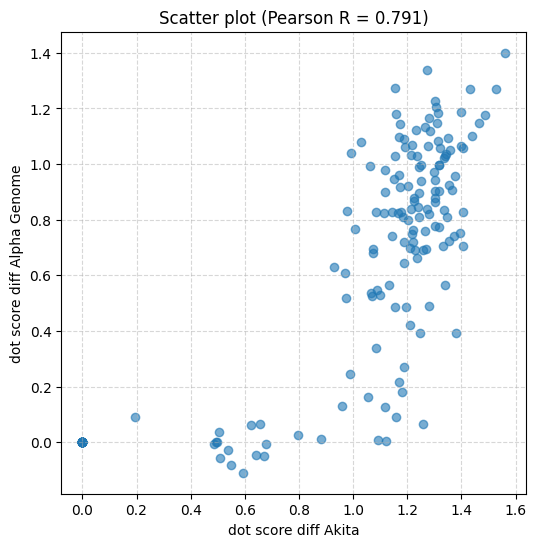

In [13]:
# Assuming df and alpha_df have the same row order
x = df["dot7_diff"].values
y = alpha_df["alpha_dot_diff"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("dot score diff Akita")
plt.ylabel("dot score diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [14]:
alpha_df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'alpha_og_dot',
       'alpha_ed_dot', 'alpha_dot_diff', 'target'],
      dtype='object')

Pearson R = 0.7785, p-value = 1.3759e-34


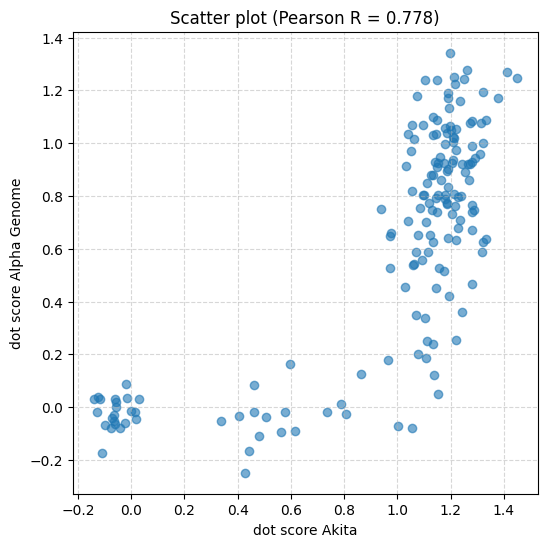

In [15]:
# Assuming df and alpha_df have the same row order
x = df["dot7_result"].values
y = alpha_df["alpha_ed_dot"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("dot score Akita")
plt.ylabel("dot score Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [16]:
df[(df["dot7_result"] > 0.2) & (df["dot7_result"] < 0.9)]

,chrom,fold,PearsonR,centered_start,centered_end,centered_flat_start,centered_flat_end,active_fraction,neutral_fraction,repressive_fraction,...,orientation_slice0,positions_slice0,init_CTCFs_num_slice1,CTCFs_num_slice1,FIMO_sum_slice1,FIMO_max_slice1,orientation_slice1,positions_slice1,target,dot7_diff
13,chr3,0,0.776279,105613312,106924032,199,313,0.482759,0.517241,0.000000,...,+,"[(1513, 1532)]",0,0,0.000000,0.000000,no,(),1.0,0.484278
16,chr3,0,0.833280,128325632,129636352,193,319,0.454545,0.545455,0.000000,...,+,"[(1669, 1688)]",0,0,0.000000,0.000000,no,(),1.0,0.794751
41,chr6,0,0.661027,65536000,66846720,193,319,0.480000,0.520000,0.000000,...,+,"[(1918, 1937)]",0,0,0.000000,0.000000,no,(),1.0,0.494419
48,chr1,1,0.710388,83357696,84668416,180,332,0.363636,0.545455,0.090909,...,-,"[(956, 975)]",0,0,0.000000,0.000000,no,(),1.0,0.536151
53,chr1,1,0.728385,88256512,89567232,206,306,0.421053,0.526316,0.052632,...,no,(),1,1,16.019732,16.019732,-,"[(857, 876)]",1.0,0.621492
71,chr1,1,0.851880,61829120,63139840,180,332,0.411765,0.529412,0.058824,...,no,(),0,0,0.000000,0.000000,no,(),1.0,0.641364
76,chr13,1,0.698864,28737536,30048256,128,384,0.444444,0.511111,0.044444,...,--,"[(274, 293), (1299, 1318)]",0,0,0.000000,0.000000,no,(),1.0,0.678325
80,chr13,1,0.857352,43833344,45144064,188,324,0.320755,0.509434,0.169811,...,no,(),1,1,16.105387,16.105387,-,"[(1723, 1742)]",1.0,0.960411
86,chr16,1,0.776455,7190528,8501248,188,324,0.464286,0.500000,0.035714,...,-+,"[(1162, 1181), (1780, 1799)]",1,1,10.868430,10.868430,-,"[(1835, 1854)]",1.0,0.503513
89,chr19,1,0.782079,17532928,18843648,112,400,0.480000,0.520000,0.000000,...,no,(),0,3,38.063376,13.491210,---,"[(1260, 1279), (1442, 1461), (1985, 2004)]",1.0,0.880693


In [23]:
alpha_df.iloc[159]

chrom                       chr9
fold                           2
PearsonR                0.841365
centered_start         101357568
centered_end           102668288
centered_flat_start          121
centered_flat_end            391
active_fraction         0.460317
neutral_fraction        0.507937
repressive_fraction     0.031746
alpha_og_dot           -0.109348
alpha_ed_dot           -0.165717
alpha_dot_diff         -0.056369
target                       1.0
Name: 159, dtype: object